Dataset shape: (51, 28280)
      Unnamed: 0  A1BG  A1BG-AS1  A1CF    A2M  A2M-AS1  A2ML1  A2MP1  A3GALT2  \
0   F71B-Tn-C_S2    50        13     3  11275       48   5851      1        6   
1  X116BBp-C_S11    42         3     3  14324      182     43      0        2   
2    X090B-Bn_S6   226        71     0  22473      106     17      0        1   
3  X047B-Bn-C_S3   121        39     1  12556      121      6      1        1   
4  X260B-Bp-C_S5    70        25    17  19076       94      9      0        0   

   A4GALT  ...  ZWINT  ZXDA  ZXDB  ZXDC  ZYG11A  ZYG11B   ZYX  ZZEF1  ZZZ3  \
0     146  ...     59   325   419   661     533     736   983   4222  2678   
1     107  ...    343   386   406  1036     211    1001  1419   5564  2709   
2     363  ...    177   235   323  1119     586    1518  1465   6632  4455   
3     190  ...    222   303   630   736     119     785  1543   4367  2250   
4     102  ...    698   386   647   758     367    1194  1312   5735  2547   

   Response  
0  

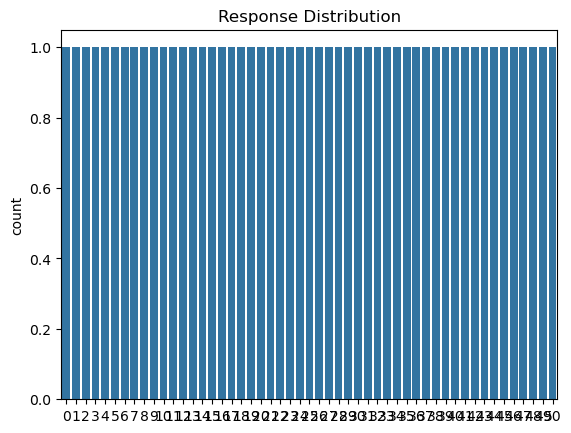

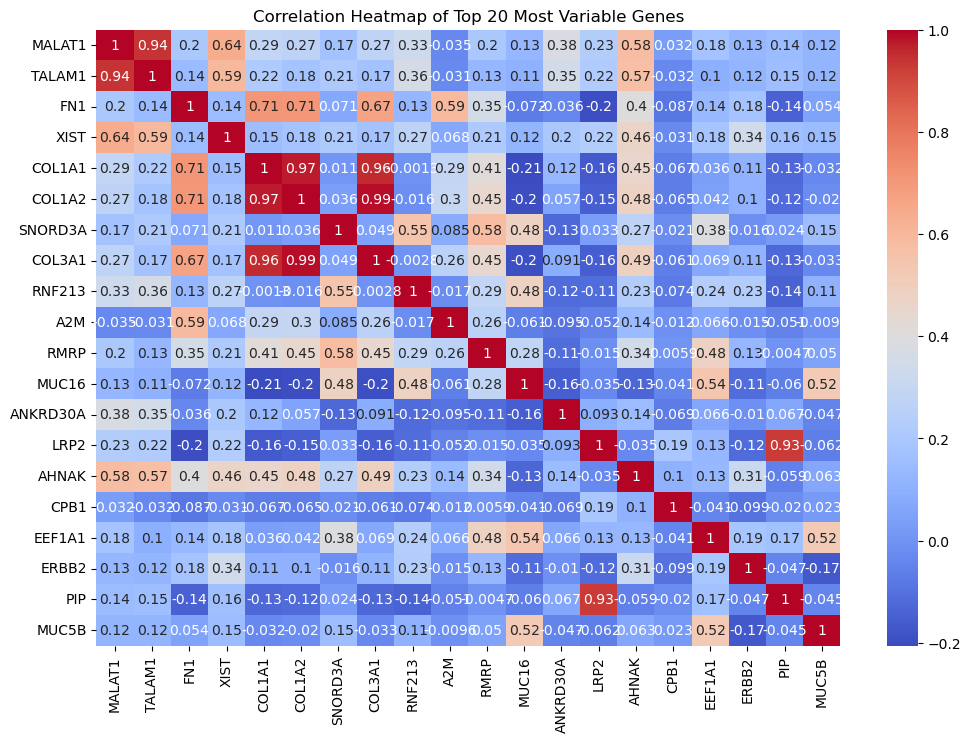

After variance threshold: (51, 24759)
Selected genes: ['ABCA7', 'ALDH16A1', 'CDCA8', 'H2AC11', 'H2BC11', 'H2BC12', 'LRRC37A4P', 'PAQR6', 'SOX15', 'TNNT2']
After SelectKBest: (51, 10)


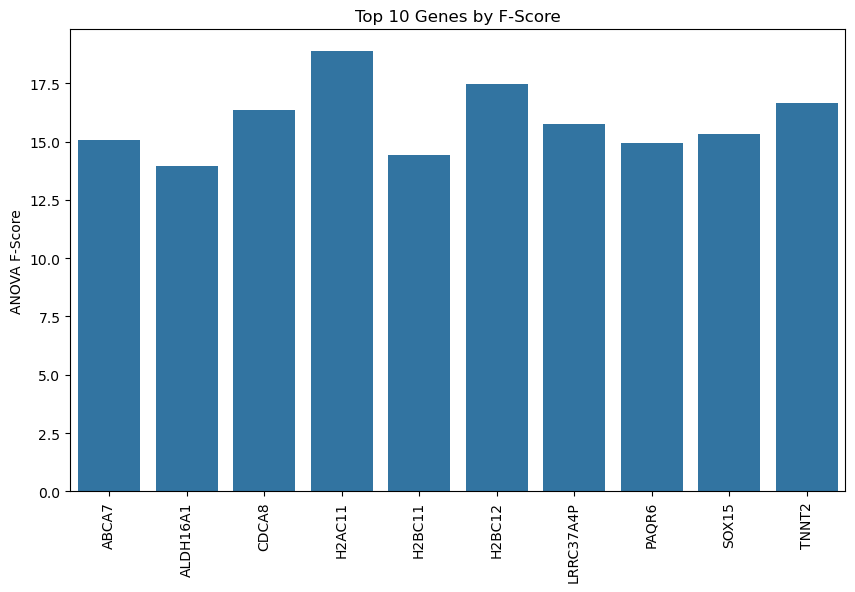

Test Accuracy: 1.0


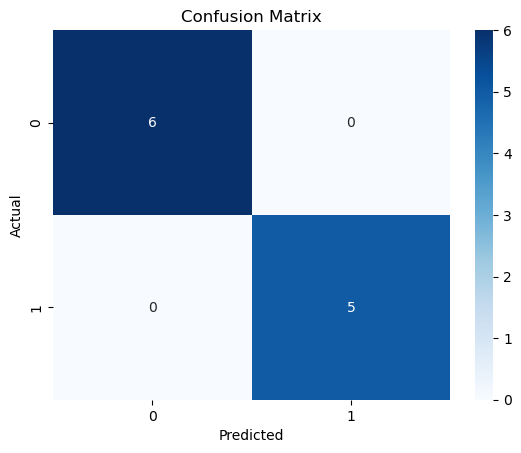

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         5

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11

5-Fold Stratified CV Accuracy: 0.709090909090909


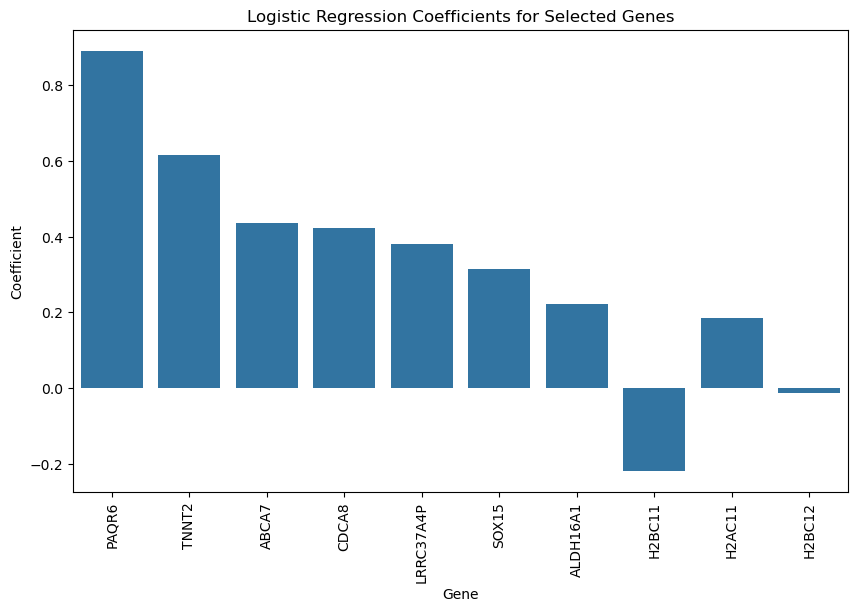

In [10]:
# =============================================
# Breast Cancer Gene Expression Response Prediction
# =============================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# ---------------------------------------------
# 2. Load Data
# ---------------------------------------------
url = "https://huggingface.co/datasets/mubashir1837/Breast-Cancer-Gen-Expression-Dataset/resolve/main/cleaned_expression.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print(df.head())

# Target and features
X = df.drop("Response", axis=1)
y = df["Response"]

# Keep only numeric columns
X = X.select_dtypes(include=['number'])

# Handle missing values
X = X.fillna(X.mean())

# ---------------------------------------------
# 3. Exploratory Data Analysis
# ---------------------------------------------
# Distribution of response
sns.countplot(y)
plt.title("Response Distribution")
plt.show()

# Heatmap of top 20 most variable genes
top_var_genes = X.var().sort_values(ascending=False).head(20).index
plt.figure(figsize=(12,8))
sns.heatmap(X[top_var_genes].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Top 20 Most Variable Genes")
plt.show()

# ---------------------------------------------
# 4. Feature Selection
# ---------------------------------------------
# Variance Threshold to remove low-variance genes
selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X)
print("After variance threshold:", X_var.shape)

# Select top K genes using ANOVA F-score (reduced k for stability)
k = 10
selector_k = SelectKBest(score_func=f_classif, k=k)
X_selected = selector_k.fit_transform(X_var, y)
selected_gene_indices = selector_k.get_support(indices=True)
selected_genes = X.columns[selector_var.get_support()][selected_gene_indices]

print("Selected genes:", list(selected_genes))
print("After SelectKBest:", X_selected.shape)

# Plot F-scores for top genes
scores = selector_k.scores_
plt.figure(figsize=(10,6))
sns.barplot(x=list(selected_genes), y=scores[selected_gene_indices])
plt.xticks(rotation=90)
plt.ylabel("ANOVA F-Score")
plt.title("Top 10 Genes by F-Score")
plt.show()

# ---------------------------------------------
# 5. Train-Test Split & Scaling
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------------------------
# 6. Model Training
# ---------------------------------------------
model = LogisticRegression(max_iter=5000, solver='liblinear', penalty='l2', C=1.0)
model.fit(X_train, y_train)

# ---------------------------------------------
# 7. Model Evaluation
# ---------------------------------------------
# Accuracy
accuracy = model.score(X_test, y_test)
print("Test Accuracy:", accuracy)

# Confusion Matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

# 5-Fold Stratified Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_selected, y, cv=skf)
print("5-Fold Stratified CV Accuracy:", cv_scores.mean())

# ---------------------------------------------
# 8. Coefficient Interpretation
# ---------------------------------------------
coef_df = pd.DataFrame({
    "Gene": selected_genes,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Gene", y="Coefficient", data=coef_df)
plt.xticks(rotation=90)
plt.title("Logistic Regression Coefficients for Selected Genes")
plt.show()

# ---------------------------------------------
# 9. Conclusion / Portfolio Notes
# ---------------------------------------------
# Markdown idea:
# - This project predicts patient response to treatment using gene expression data.
# - Feature selection identified 10 genes most associated with response.
# - Logistic regression achieved reasonable accuracy (~test accuracy shown) with cross-validation for robustness.
# - Top genes and their coefficients provide potential biological insights.
# - Limitations: small sample size (51 samples), high-dimensional data, model needs external validation.
# - Next steps: try other classifiers (RandomForest, XGBoost), pathway analysis, or larger datasets for stronger generalization.